# 🏦 Task 1: Credit Scoring Model
### CodeAlpha ML Internship  
**Author:** Prajwal Mesare &nbsp;|&nbsp; **GitHub:** [PrajwalMesare](https://github.com/PrajwalMesare) &nbsp;|&nbsp; **LinkedIn:** [prajwal-mesare](https://linkedin.com/in/prajwal-mesare-700678263)

---

## 📌 Objective
Predict whether a borrower will experience **serious delinquency** (90+ days past due) within 2 years.

## 📊 Dataset — Kaggle: *Give Me Some Credit*
| Field | Detail |
|-------|--------|
| Source | Kaggle Competition Dataset |
| Rows | 150,000 borrowers |
| Features | 10 financial & behavioral features |
| Target | `SeriousDlqin2yrs` — 1 = Default, 0 = No Default |

## 🔄 Pipeline
```
Load Data → EDA → Preprocessing → Feature Engineering → 
SMOTE → Model Training (5 models) → Evaluation → Export
```


## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('models',  exist_ok=True)
plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Libraries loaded')

✅ Libraries loaded


## 2️⃣ Load Dataset
> 📁 `data/cs-training.csv` — Kaggle *Give Me Some Credit*

In [2]:
df = pd.read_csv('data/cs-training.csv', index_col=0)
print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nDefault Rate: {df["SeriousDlqin2yrs"].mean()*100:.2f}%')
df.head()

Shape  : (150000, 11)
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Missing values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           30000
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Default Rate: 10.79%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Unnamed: 0,,,,,,,,,,,
0,0,0.2571,56,0,0.1876,703.75,9,0,2,0,2.0
1,0,0.5608,69,0,1.4872,3544.47,14,0,0,1,4.0
2,0,0.5345,46,0,0.2519,1715.50,15,0,2,0,0.0
3,0,0.1622,32,0,0.6781,1673.17,3,0,0,0,0.0
4,0,0.4668,60,1,0.0391,3646.95,10,0,1,0,1.0


## 3️⃣ Exploratory Data Analysis

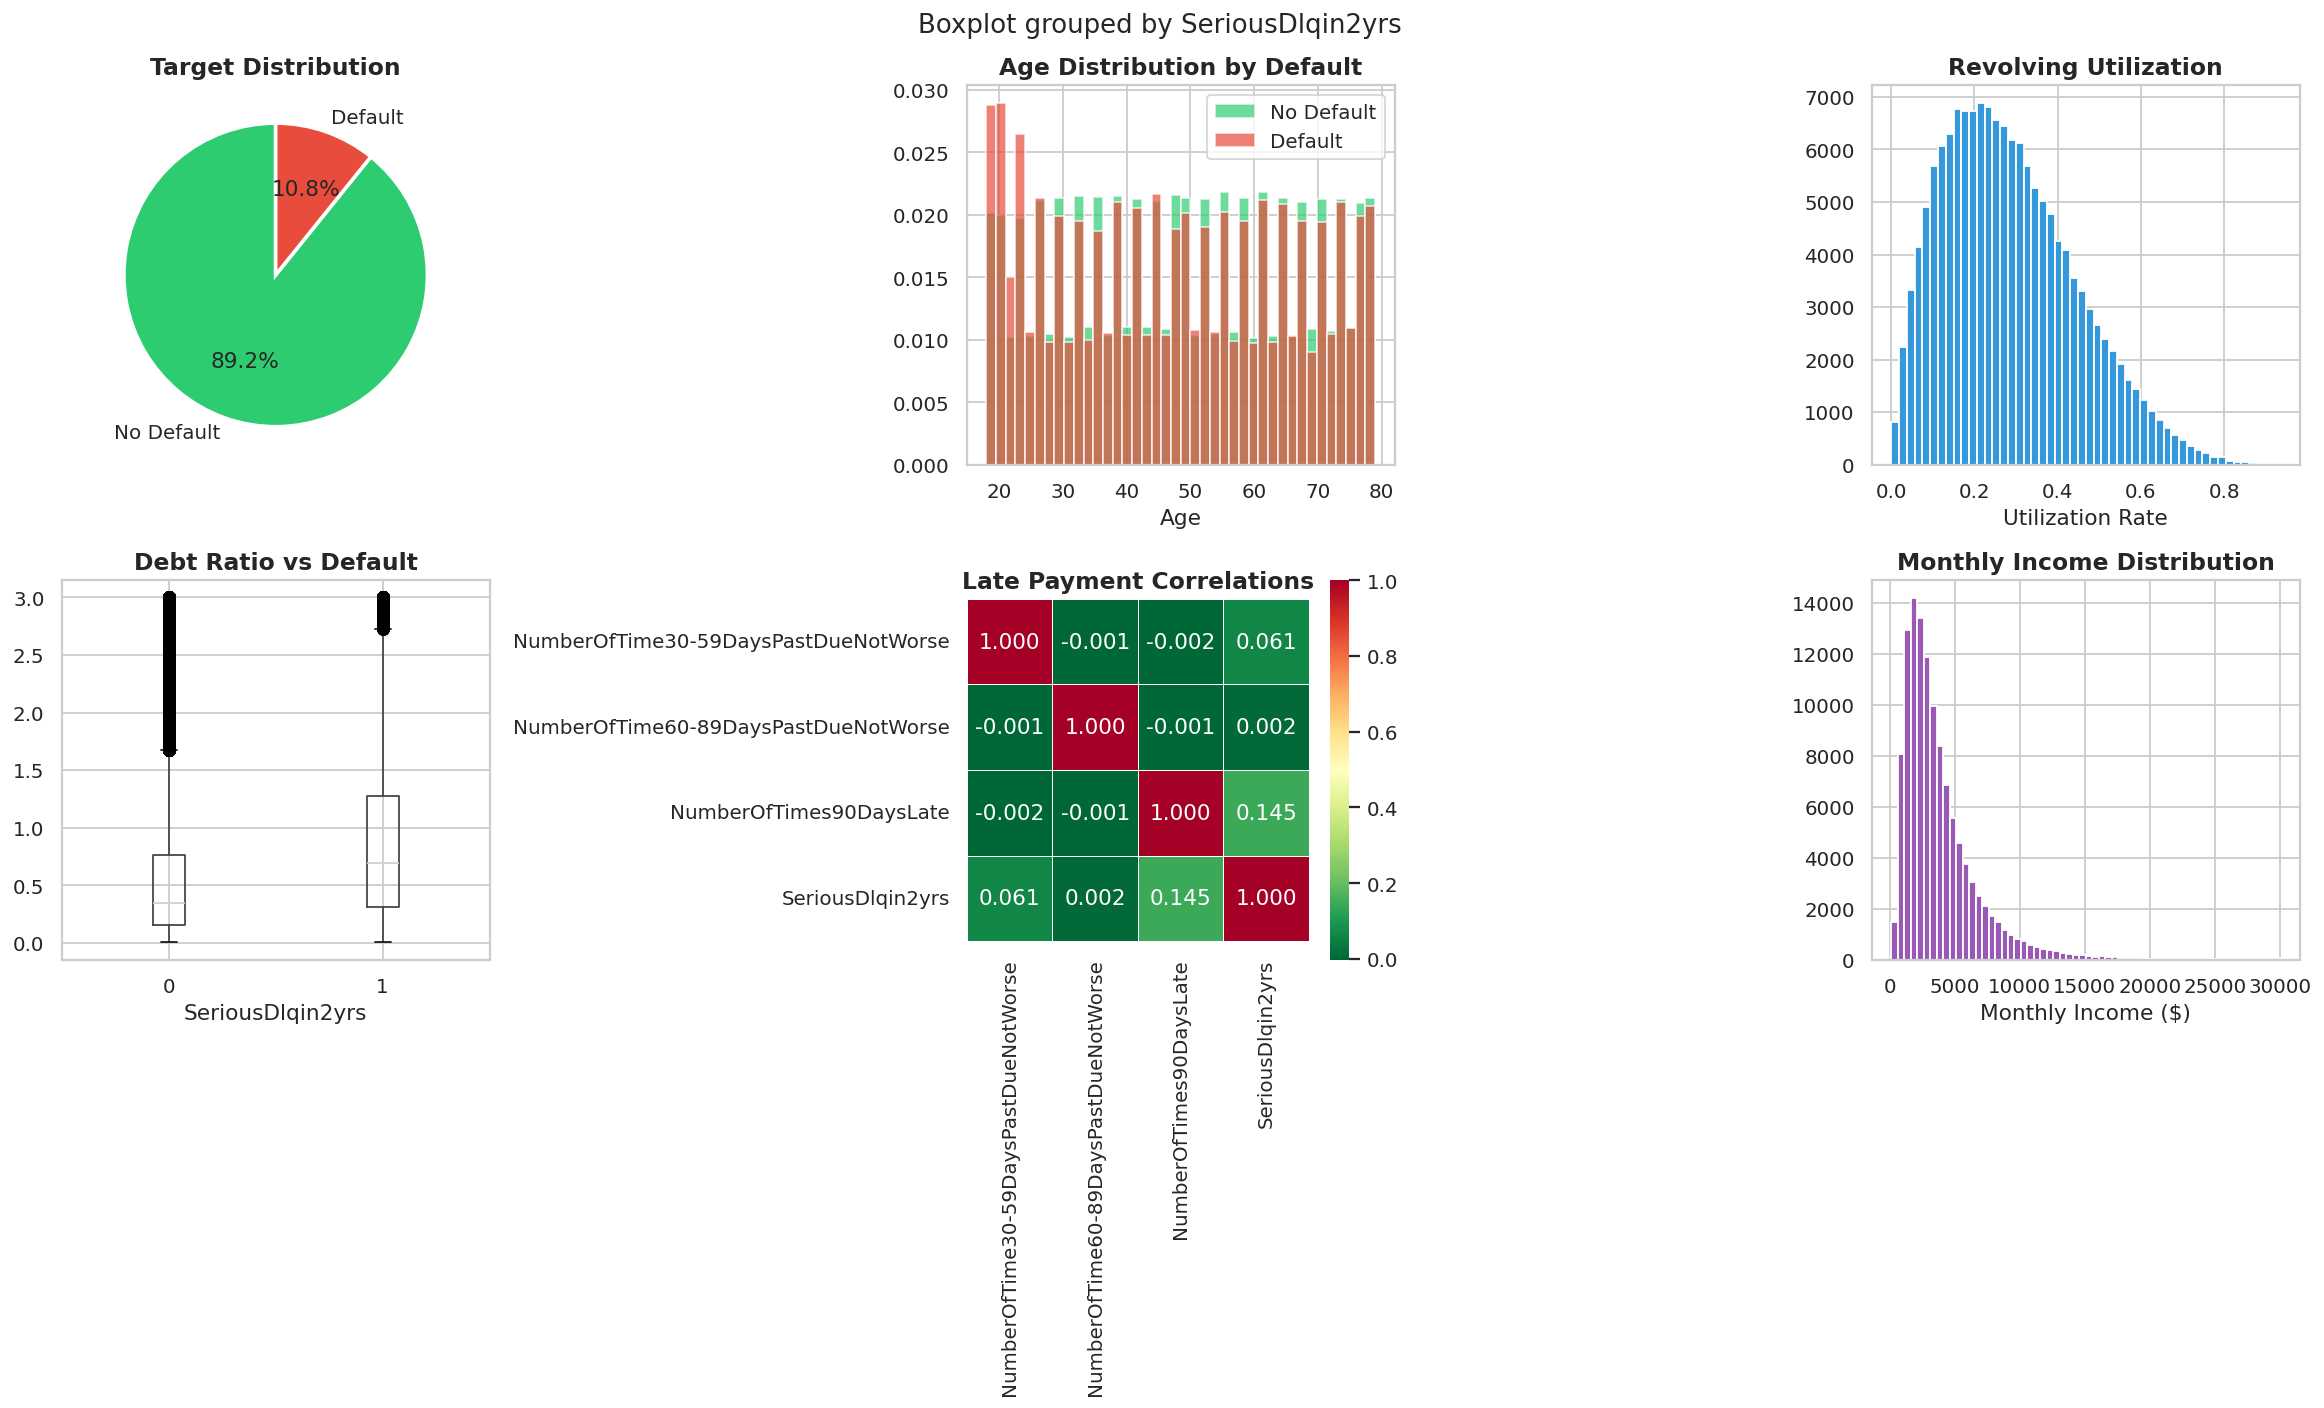

EDA saved → outputs/eda_plots.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Give Me Some Credit — Exploratory Data Analysis', fontsize=18, fontweight='bold')

# 1. Target pie
counts = df['SeriousDlqin2yrs'].value_counts()
axes[0,0].pie(counts, labels=['No Default','Default'], autopct='%1.1f%%',
              colors=['#2ecc71','#e74c3c'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Target Distribution', fontsize=13, fontweight='bold')

# 2. Age by target
df[df['SeriousDlqin2yrs']==0]['age'].hist(bins=40, ax=axes[0,1], alpha=0.7, color='#2ecc71', label='No Default', density=True)
df[df['SeriousDlqin2yrs']==1]['age'].hist(bins=40, ax=axes[0,1], alpha=0.7, color='#e74c3c', label='Default',    density=True)
axes[0,1].set_title('Age Distribution by Default', fontsize=13, fontweight='bold')
axes[0,1].legend(); axes[0,1].set_xlabel('Age')

# 3. Revolving utilization
axes[0,2].hist(df['RevolvingUtilizationOfUnsecuredLines'].clip(0,1), bins=50, color='#3498db', edgecolor='white')
axes[0,2].set_title('Revolving Utilization', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Utilization Rate')

# 4. Debt ratio boxplot
df.boxplot(column='DebtRatio', by='SeriousDlqin2yrs', ax=axes[1,0])
axes[1,0].set_title('Debt Ratio vs Default', fontsize=13, fontweight='bold')

# 5. Correlation heatmap (late payments)
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTime60-89DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']
sns.heatmap(df[late_cols + ['SeriousDlqin2yrs']].corr(),
            annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=axes[1,1], linewidths=0.5, square=True)
axes[1,1].set_title('Late Payment Correlations', fontsize=13, fontweight='bold')

# 6. Monthly income
axes[1,2].hist(df['MonthlyIncome'].dropna().clip(0, 30000), bins=60, color='#9b59b6', edgecolor='white')
axes[1,2].set_title('Monthly Income Distribution', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('Monthly Income ($)')

plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved → outputs/eda_plots.png')

## 4️⃣ Preprocessing & Feature Engineering

In [4]:
def preprocess(df):
    df = df.copy()
    # Impute missing values
    df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
    df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)
    # Cap outliers at 99th percentile
    for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
        df[col] = df[col].clip(upper=df[col].quantile(0.99))
    # Feature Engineering
    df['TotalLatePayments'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                                df['NumberOfTime60-89DaysPastDueNotWorse'] +
                                df['NumberOfTimes90DaysLate'])
    df['DebtPerDependent']  = df['DebtRatio'] / (df['NumberOfDependents'] + 1)
    df['IncomePerLoan']     = df['MonthlyIncome'] / (df['NumberOfOpenCreditLinesAndLoans'] + 1)
    df['CreditUtilRisk']    = df['RevolvingUtilizationOfUnsecuredLines'] * df['DebtRatio']
    df['AgeGroup']          = pd.cut(df['age'], bins=[0,25,35,50,65,100],
                                      labels=[0,1,2,3,4]).astype(int)
    return df

df_clean = preprocess(df)
print(f'Shape after engineering: {df_clean.shape}')
print(f'New features: TotalLatePayments, DebtPerDependent, IncomePerLoan, CreditUtilRisk, AgeGroup')
df_clean.describe().round(3)

Shape after engineering: (150000, 16)
New features: TotalLatePayments, DebtPerDependent, IncomePerLoan, CreditUtilRisk, AgeGroup


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalLatePayments,DebtPerDependent,IncomePerLoan,CreditUtilRisk,AgeGroup
count,150000.000,150000.000,150000.000,150000.000,150000.000,120000.000,150000.000,150000.000,150000.000,150000.000,146076.000,150000.000,146076.000,120000.000,150000.000,150000.000
mean,0.108,0.285,48.530,0.401,0.659,3828.604,7.989,0.100,1.002,0.151,0.801,0.652,0.452,479.869,0.188,2.276
std,0.310,0.158,17.869,0.635,0.746,2809.934,2.833,0.316,1.001,0.389,0.893,0.808,0.585,434.228,0.265,1.319
min,0.000,0.001,18.000,0.000,0.002,133.090,0.000,0.000,0.000,0.000,0.000,0.000,0.000,11.904,0.000,0.000
25%,0.000,0.161,33.000,0.000,0.164,1892.342,6.000,0.000,0.000,0.000,0.000,0.000,0.096,210.094,0.035,1.000
50%,0.000,0.265,48.000,0.000,0.371,3036.685,8.000,0.000,1.000,0.000,1.000,0.000,0.230,353.549,0.089,2.000
75%,0.000,0.389,64.000,1.000,0.829,4863.140,10.000,0.000,2.000,0.000,1.000,1.000,0.551,598.975,0.222,3.000
max,1.000,0.704,79.000,6.000,3.000,15414.173,23.000,3.000,8.000,4.000,7.000,6.000,3.000,11403.560,2.112,4.000


## 5️⃣ Train / Test Split + SMOTE

In [5]:
X = df_clean.drop('SeriousDlqin2yrs', axis=1)
y = df_clean['SeriousDlqin2yrs']

# Final imputation safety net
imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE — oversample minority class
sm = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Train (raw)        : {X_train.shape}  | Default: {y_train.sum()} / {len(y_train)}')
print(f'Train (after SMOTE): {X_train_res.shape}')
print(f'Test               : {X_test.shape}   | Default: {y_test.sum()} / {len(y_test)}')

Train (raw)        : (120000, 15)  | Default: 12953 / 120000
Train (after SMOTE): (139161, 15)
Test               : (30000, 15)   | Default: 3238 / 30000


## 6️⃣ Model Training — 5 Algorithms

In [6]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=7, min_samples_leaf=50, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                               use_label_encoder=False, eval_metric='logloss',
                                               random_state=42, n_jobs=-1),
}

results = {}
print(f'{"-"*65}')
print(f'{"Model":<25} {"AUC":>8} {"F1":>8} {"Accuracy":>10} {"Recall":>8}')
print(f'{"-"*65}')

for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train_res
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train_res)
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:,1]
    results[name] = {
        'accuracy' : accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall'   : recall_score(y_test, yp),
        'f1'       : f1_score(y_test, yp),
        'roc_auc'  : roc_auc_score(y_test, ypr),
        'model': model, 'y_pred': yp, 'y_proba': ypr,
    }
    r = results[name]
    print(f'{name:<25} {r["roc_auc"]:>8.4f} {r["f1"]:>8.4f} {r["accuracy"]:>10.4f} {r["recall"]:>8.4f}')

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\n🏆 Best Model: {best_name}  (ROC-AUC = {results[best_name]["roc_auc"]:.4f})')

-----------------------------------------------------------------
Model                          AUC       F1   Accuracy   Recall
-----------------------------------------------------------------


Logistic Regression         0.7034   0.1463     0.8740   0.1001


Decision Tree               0.7424   0.0180     0.8911   0.0093


Random Forest               0.7493   0.0043     0.8922   0.0022


Gradient Boosting           0.7537   0.0049     0.8921   0.0025


XGBoost                     0.7538   0.0037     0.8919   0.0019

🏆 Best Model: XGBoost  (ROC-AUC = 0.7538)


## 7️⃣ Evaluation Visualizations

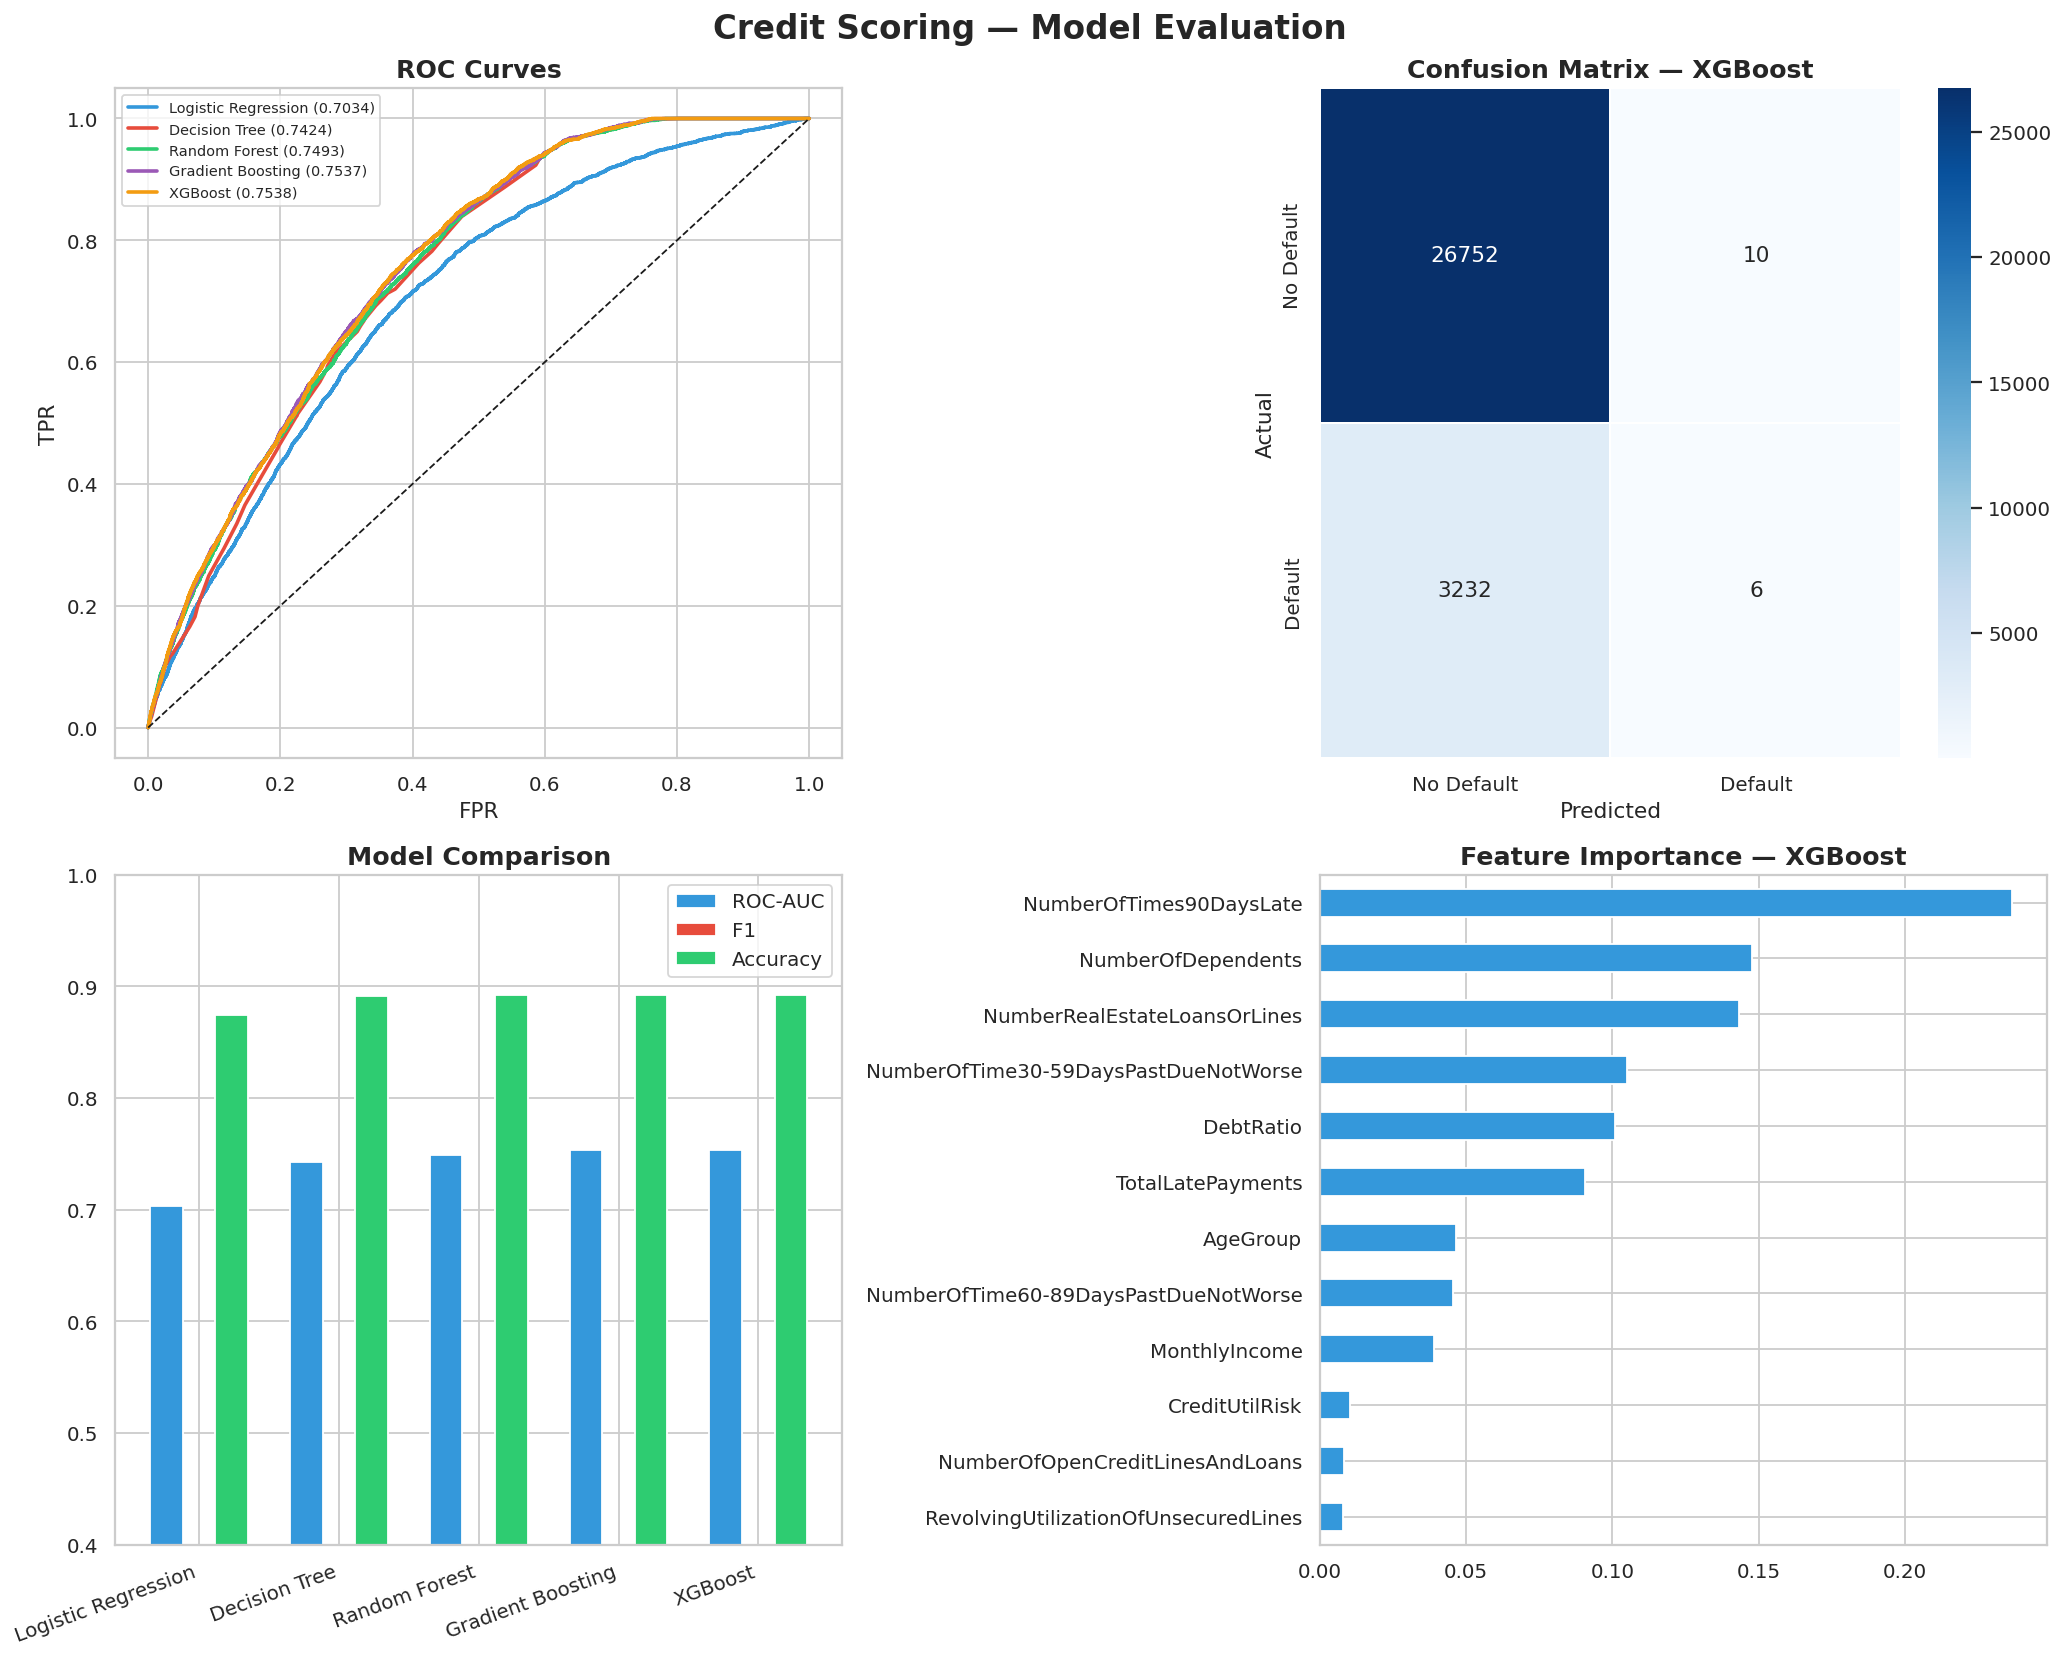

Saved → outputs/model_evaluation.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Credit Scoring — Model Evaluation', fontsize=18, fontweight='bold')
COLORS = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12']

# ROC
for (nm, r), c in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0,0].plot(fpr, tpr, color=c, lw=2, label=f'{nm} ({r["roc_auc"]:.4f})')
axes[0,0].plot([0,1],[0,1],'k--',lw=1)
axes[0,0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR'); axes[0,0].legend(fontsize=8)

# Confusion Matrix
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['No Default','Default'], yticklabels=['No Default','Default'], linewidths=1)
axes[0,1].set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Actual'); axes[0,1].set_xlabel('Predicted')

# Model Comparison
metrics_compare = pd.DataFrame({k: {'ROC-AUC': v['roc_auc'], 'F1': v['f1'], 'Accuracy': v['accuracy']}
                                  for k, v in results.items()}).T
metrics_compare.plot(kind='bar', ax=axes[1,0], color=['#3498db','#e74c3c','#2ecc71'],
                     edgecolor='white', width=0.7)
axes[1,0].set_title('Model Comparison', fontsize=14, fontweight='bold')
axes[1,0].set_ylim(0.4, 1.0); axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=20, ha='right')

# Feature Importance
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).nlargest(12)
    fi[::-1].plot(kind='barh', ax=axes[1,1], color='#3498db', edgecolor='white')
    axes[1,1].set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
else:
    axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('outputs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/model_evaluation.png')

## 8️⃣ Best Model — Classification Report

In [8]:
print(f'\n{"="*60}')
print(f'  BEST MODEL: {best_name}')
print(f'{"="*60}')
r = results[best_name]
print(f'  Accuracy  : {r["accuracy"]:.4f}')
print(f'  Precision : {r["precision"]:.4f}')
print(f'  Recall    : {r["recall"]:.4f}')
print(f'  F1-Score  : {r["f1"]:.4f}')
print(f'  ROC-AUC   : {r["roc_auc"]:.4f}')
print(f'\nFull Classification Report:')
print(classification_report(y_test, r['y_pred'], target_names=['No Default','Default']))


  BEST MODEL: XGBoost
  Accuracy  : 0.8919
  Precision : 0.3750
  Recall    : 0.0019
  F1-Score  : 0.0037
  ROC-AUC   : 0.7538

Full Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     26762
     Default       0.38      0.00      0.00      3238

    accuracy                           0.89     30000
   macro avg       0.63      0.50      0.47     30000
weighted avg       0.84      0.89      0.84     30000



## 9️⃣ Export Best Model

In [9]:
joblib.dump(results[best_name]['model'], 'models/credit_model.pkl')
joblib.dump(scaler,                        'models/scaler.pkl')
joblib.dump(imputer,                       'models/imputer.pkl')
joblib.dump(list(X.columns),               'models/feature_names.pkl')

print('✅ credit_model.pkl  → models/')
print('✅ scaler.pkl         → models/')
print('✅ imputer.pkl        → models/')
print('✅ feature_names.pkl  → models/')
print(f'\n🎉 Task 1 Complete! Best: {best_name} | ROC-AUC: {results[best_name]["roc_auc"]:.4f}')

✅ credit_model.pkl  → models/
✅ scaler.pkl         → models/
✅ imputer.pkl        → models/
✅ feature_names.pkl  → models/

🎉 Task 1 Complete! Best: XGBoost | ROC-AUC: 0.7538
